In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('datasets\\mercc_cleaned.csv')
brand_unq = pd.read_csv('datasets\\brandnames.csv')

In [3]:
# Feature Selection

# Filtering only unique item ID is missing
df = data[['item_id', 'item_condition_name', 'price', 'event_id', 'brand_name', 'c0_name', 'shipper_id']]
brand_map = dict(zip(brand_unq['brand'], brand_unq['Category']))
df = df.loc[df['item_condition_name'] != 'unknown',:]
df = df.loc[df['event_id'] != 'item_like',:]

df['event_id'] = df['event_id'].replace({
    'item_view':'not_bought',
    'item_like':'not_bought',
    'item_add_to_cart_tap':'not_bought',
    'buy_start':'not_bought',
    'offer_make':'not_bought'
})

df['brand_name'] = df['brand_name'].map(brand_map)
df['brand_name'] = df['brand_name'].fillna('Uncategorized')

ordinal_encoder = OrdinalEncoder(
    categories = [[ 'Fair', 'Poor', 'Good', 'New', 'Like new']]
)

ordinal_encoder2 = OrdinalEncoder(
    categories = [['not_bought', 'buy_comp']]
)

ranking = [['Uncategorized', 'Mid-Range / Premium','Mass Market / Common','Luxury / Niche High-End']]
encoder_brand = OrdinalEncoder(categories=ranking)

df[['item_condition_name']] = ordinal_encoder.fit_transform(df[['item_condition_name']])
df[['event_id']] = ordinal_encoder2.fit_transform(df[['event_id']])
df[['brand_name']] = encoder_brand.fit_transform(df[['brand_name']])

df = df[['item_condition_name', 'price', 'brand_name', 'c0_name','shipper_id', 'event_id']]

# One hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        (
            'onehot',
            OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
            ['c0_name']
        )
    ],
    remainder='passthrough'
)

encoded_data = preprocessor.fit_transform(df)

feature_name = preprocessor.get_feature_names_out()

encoded_df = pd.DataFrame(encoded_data, columns=feature_name)
list(feature_name)

['onehot__c0_name_Arts & Crafts',
 'onehot__c0_name_Beauty',
 'onehot__c0_name_Books',
 'onehot__c0_name_Electronics',
 'onehot__c0_name_Garden & Outdoor',
 'onehot__c0_name_Handmade',
 'onehot__c0_name_Home',
 'onehot__c0_name_Kids',
 'onehot__c0_name_Men',
 'onehot__c0_name_Office',
 'onehot__c0_name_Other',
 'onehot__c0_name_Pet Supplies',
 'onehot__c0_name_Sports & outdoors',
 'onehot__c0_name_Tools',
 'onehot__c0_name_Toys & Collectibles',
 'onehot__c0_name_Vintage & collectibles',
 'onehot__c0_name_Women',
 'remainder__item_condition_name',
 'remainder__price',
 'remainder__brand_name',
 'remainder__shipper_id',
 'remainder__event_id']

Cross-Val Accuracy: 0.60 (+/- 0.01)
[0.58332889 0.59905261 0.59800462 0.6004131  0.6038772 ]


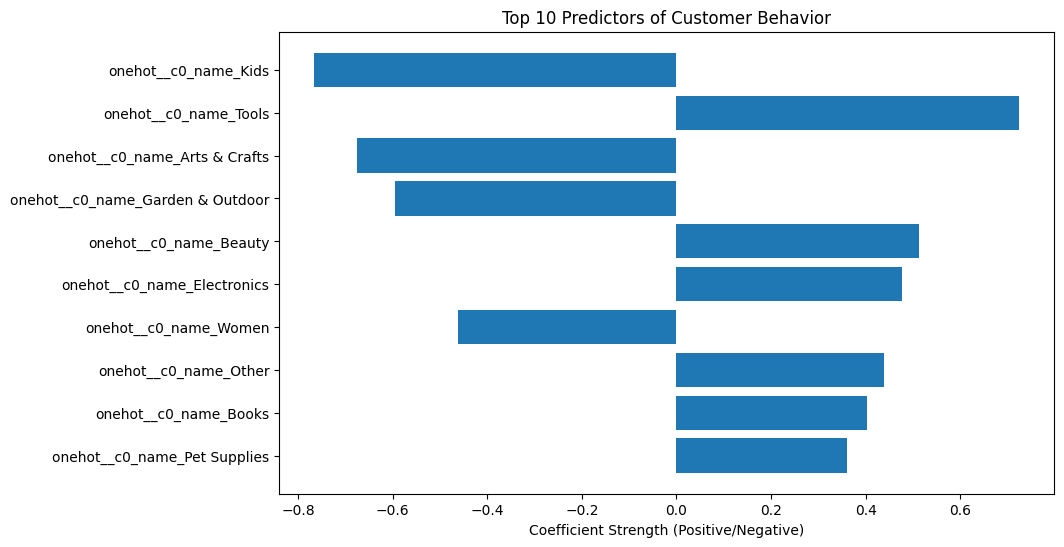

                                   Feature  Coefficient  Abs_Importance
7                     onehot__c0_name_Kids    -0.765538        0.765538
13                   onehot__c0_name_Tools     0.724474        0.724474
0            onehot__c0_name_Arts & Crafts    -0.676462        0.676462
4         onehot__c0_name_Garden & Outdoor    -0.595125        0.595125
1                   onehot__c0_name_Beauty     0.513670        0.513670
3              onehot__c0_name_Electronics     0.477887        0.477887
16                   onehot__c0_name_Women    -0.461249        0.461249
10                   onehot__c0_name_Other     0.438137        0.438137
2                    onehot__c0_name_Books     0.403670        0.403670
11            onehot__c0_name_Pet Supplies     0.360978        0.360978
9                   onehot__c0_name_Office    -0.328445        0.328445
8                      onehot__c0_name_Men    -0.268212        0.268212
5                 onehot__c0_name_Handmade     0.247291        0

In [9]:
# Your existing setup
X, y = encoded_df.iloc[:,:20], encoded_df.iloc[:,-1]
log_reg_model = LogisticRegression(class_weight='balanced', max_iter=500)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. Run Cross-Validation to check stability
scores = cross_val_score(log_reg_model, X, y, cv=kf)
print(f"Cross-Val Accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")
print(scores)

# 2. Fit the model once more to extract coefficients
log_reg_model.fit(X, y)

# 3. Get variable rankings
# Since you used .iloc[:, :20], X.columns already contains the names
importance = log_reg_model.coef_[0]
feature_names = X.columns

# 4. Create and Sort DataFrame
ranking_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': importance,
    'Abs_Importance': abs(importance)
}).sort_values(by='Abs_Importance', ascending=False)

# 5. Visualize the top predictors
plt.figure(figsize=(10, 6))
plt.barh(ranking_df['Feature'].head(10), ranking_df['Coefficient'].head(10))
plt.xlabel('Coefficient Strength (Positive/Negative)')
plt.title('Top 10 Predictors of Customer Behavior')
plt.gca().invert_yaxis()
plt.show()

print(ranking_df)

In [ ]:
ranking_df.to_csv('Customer-Behavior-Analysis---mercec-dataset\\Results')